正在读取数据文件: /home/lgx/Project/AFP/src/il_capture/data/experiments/experiment_1773129382.csv ...


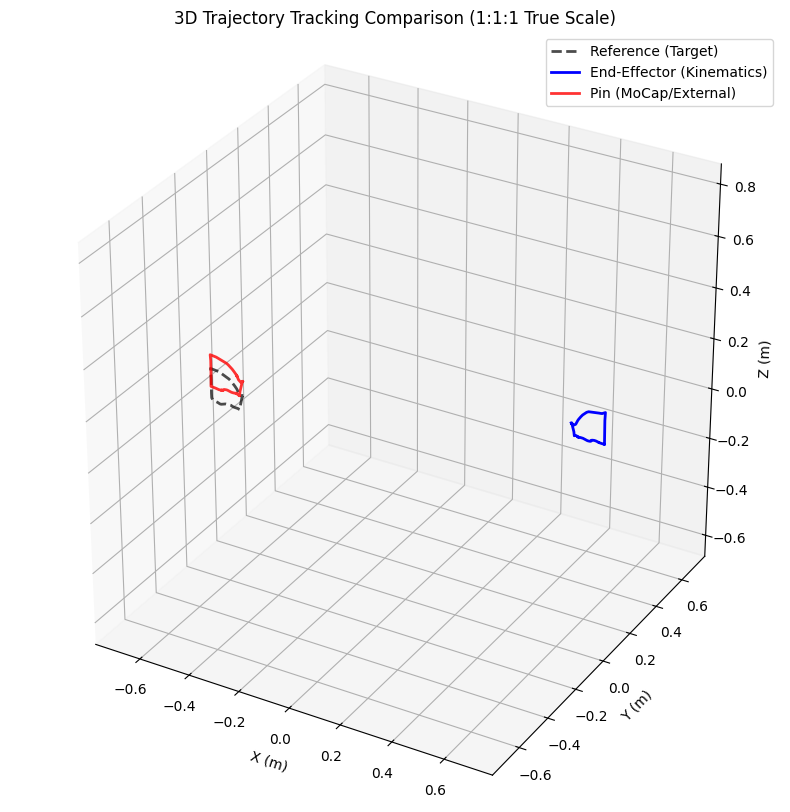

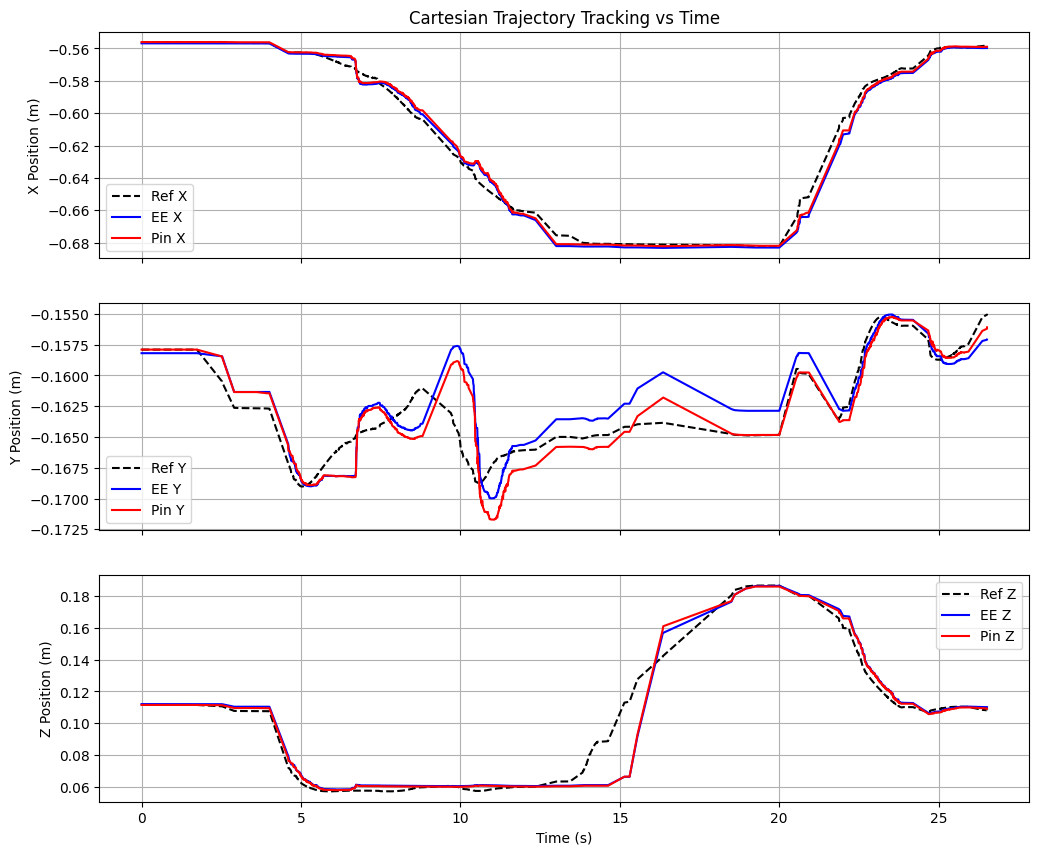

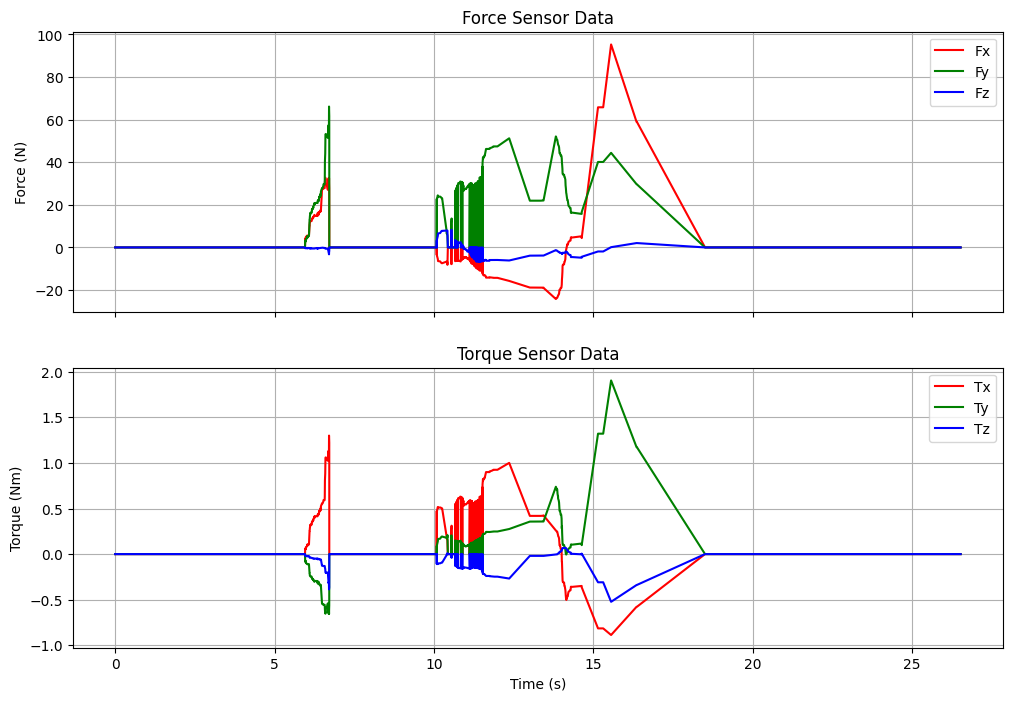

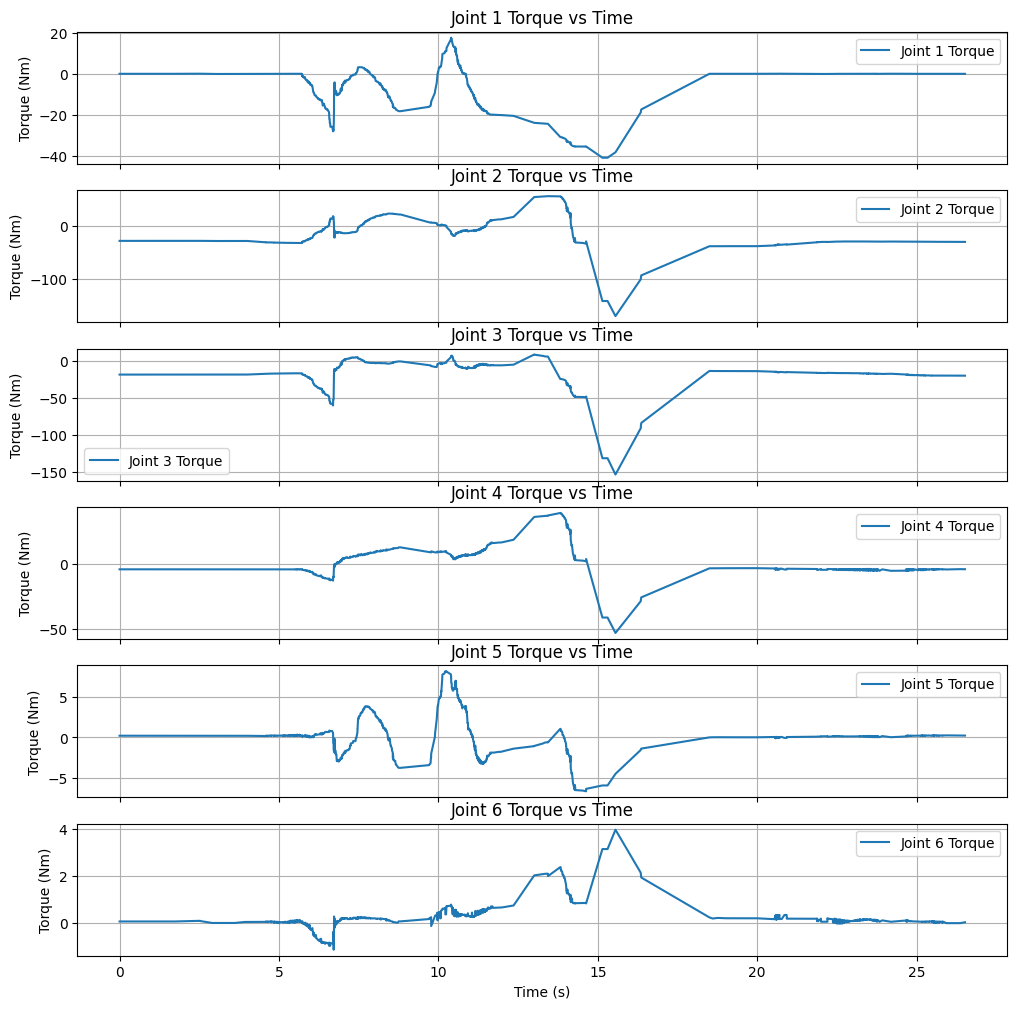

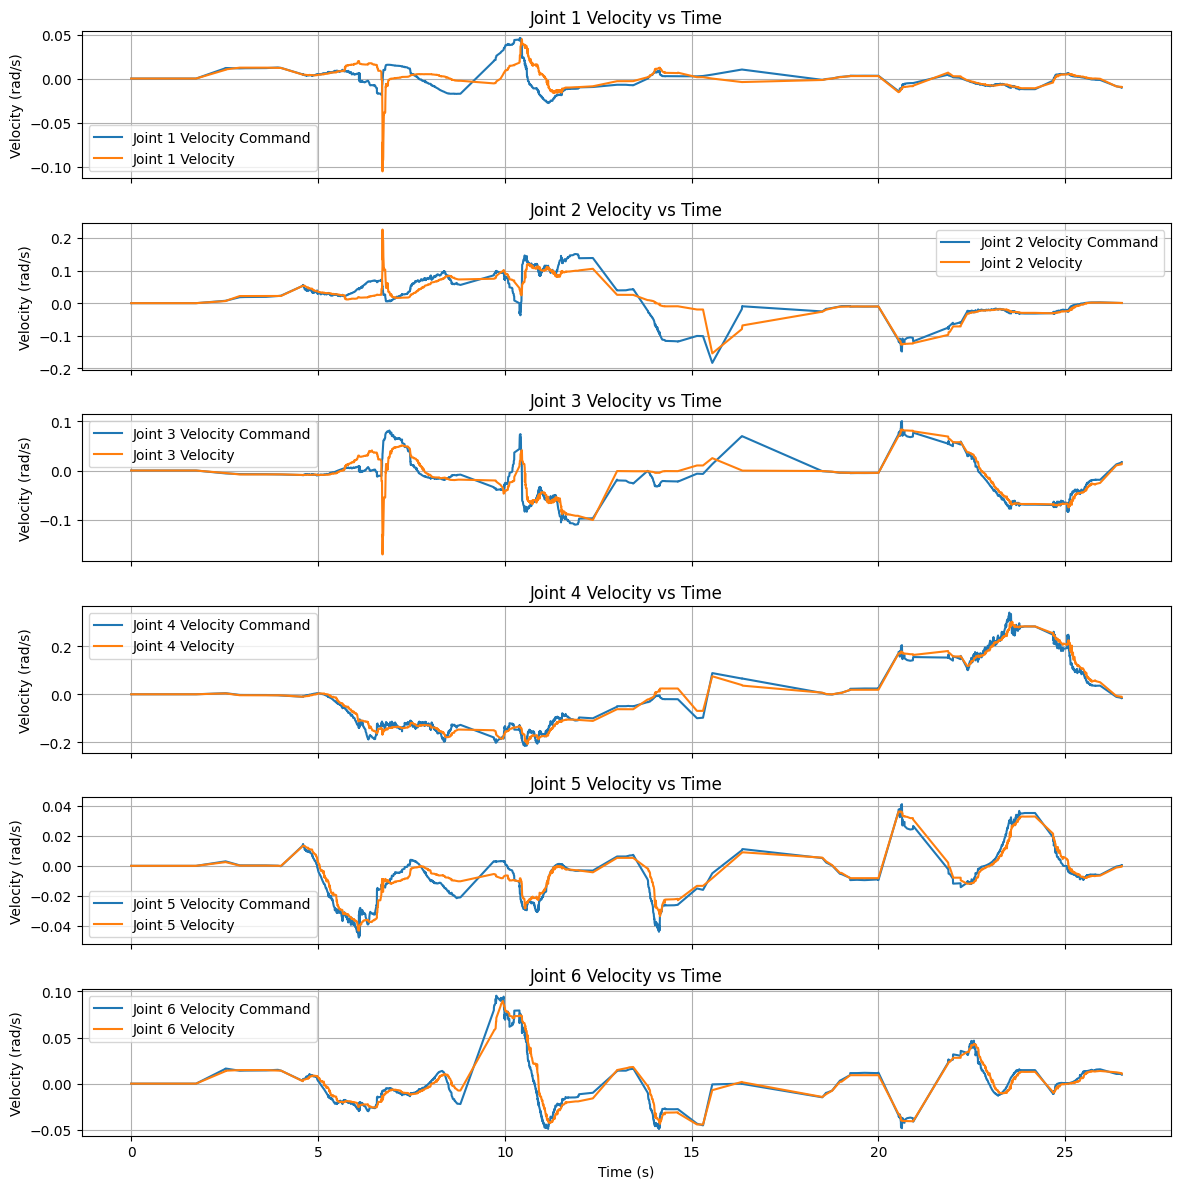

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def set_axes_equal(ax):
    """强制 3D 坐标轴的物理比例保持 1:1:1"""
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()

    x_range = abs(x_limits[1] - x_limits[0])
    x_middle = np.mean(x_limits)
    y_range = abs(y_limits[1] - y_limits[0])
    y_middle = np.mean(y_limits)
    z_range = abs(z_limits[1] - z_limits[0])
    z_middle = np.mean(z_limits)

    plot_radius = 0.5 * max([x_range, y_range, z_range])
    ax.set_xlim3d([x_middle - plot_radius, x_middle + plot_radius])
    ax.set_ylim3d([y_middle - plot_radius, y_middle + plot_radius])
    ax.set_zlim3d([z_middle - plot_radius, z_middle + plot_radius])

def plot_robot_data(csv_file):
    print(f"正在读取数据文件: {csv_file} ...")
    df = pd.read_csv(csv_file)
    
    # 如果时间戳是以秒/纳秒形式记录的绝对时间，减去初始值使其从 0 开始，方便观察
    time = df['time_stamp'] - df['time_stamp'].iloc[0]

    # ==========================================
    # 1. 绘制 3D 轨迹对比 (Ref vs EE vs Pin)
    # ==========================================
    fig = plt.figure(figsize=(12, 10))
    ax3d = fig.add_subplot(111, projection='3d')
    
    # 参考轨迹 (目标指令) - 黑色虚线
    ax3d.plot(df['ref_pose_x'], df['ref_pose_y'], df['ref_pose_z'], 
              label='Reference (Target)', color='black', linestyle='--', linewidth=2, alpha=0.7)
    
    # 实际末端轨迹 (运动学计算) - 蓝色实线
    ax3d.plot(df['ee_pose_x'], df['ee_pose_y'], df['ee_pose_z'], 
              label='End-Effector (Kinematics)', color='blue', linewidth=2)
    
    # Pin 轨迹 (动捕/外部标记) - 红色实线
    ax3d.plot(df['pin_x'], df['pin_y'], df['pin_z'], 
              label='Pin (MoCap/External)', color='red', linewidth=2, alpha=0.8)

    set_axes_equal(ax3d)
    ax3d.set_box_aspect([1, 1, 1])
    ax3d.set_title('3D Trajectory Tracking Comparison (1:1:1 True Scale)')
    ax3d.set_xlabel('X (m)')
    ax3d.set_ylabel('Y (m)')
    ax3d.set_zlabel('Z (m)')
    ax3d.legend()
    
    # ==========================================
    # 2. 绘制 XYZ 各轴的时间序列追踪对比
    # ==========================================
    fig_xyz, axes_xyz = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    
    # X 轴
    axes_xyz[0].plot(time, df['ref_pose_x'], 'k--', label='Ref X')
    axes_xyz[0].plot(time, -df['ee_pose_x'], 'b-', label='EE X')
    axes_xyz[0].plot(time, df['pin_x'], 'r-', label='Pin X')
    axes_xyz[0].set_ylabel('X Position (m)')
    axes_xyz[0].set_title('Cartesian Trajectory Tracking vs Time')
    axes_xyz[0].legend()
    axes_xyz[0].grid(True)
    
    # Y 轴
    axes_xyz[1].plot(time, df['ref_pose_y'], 'k--', label='Ref Y')
    axes_xyz[1].plot(time, -df['ee_pose_y'], 'b-', label='EE Y')
    axes_xyz[1].plot(time, df['pin_y'], 'r-', label='Pin Y')
    axes_xyz[1].set_ylabel('Y Position (m)')
    axes_xyz[1].legend()
    axes_xyz[1].grid(True)
    
    # Z 轴
    axes_xyz[2].plot(time, df['ref_pose_z']+0.055, 'k--', label='Ref Z')
    axes_xyz[2].plot(time, df['ee_pose_z'], 'b-', label='EE Z')
    axes_xyz[2].plot(time, df['pin_z'], 'r-', label='Pin Z')
    axes_xyz[2].set_ylabel('Z Position (m)')
    axes_xyz[2].set_xlabel('Time (s)')
    axes_xyz[2].legend()
    axes_xyz[2].grid(True)
    
    # ==========================================
    # 3. 绘制六维力/力矩传感器数据
    # ==========================================
    fig_ft, (ax_f, ax_t) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    
    # 力 (Forces: fx, fy, fz)
    ax_f.plot(time, df['fx'], label='Fx', color='r')
    ax_f.plot(time, df['fy'], label='Fy', color='g')
    ax_f.plot(time, df['fz'], label='Fz', color='b')
    ax_f.set_title('Force Sensor Data')
    ax_f.set_ylabel('Force (N)')
    ax_f.legend()
    ax_f.grid(True)
    
    # 力矩 (Torques: tx, ty, tz)
    ax_t.plot(time, df['tx'], label='Tx', color='r')
    ax_t.plot(time, df['ty'], label='Ty', color='g')
    ax_t.plot(time, df['tz'], label='Tz', color='b')
    ax_t.set_title('Torque Sensor Data')
    ax_t.set_ylabel('Torque (Nm)')
    ax_t.set_xlabel('Time (s)')
    ax_t.legend()
    ax_t.grid(True)
    
    # 绘制关节力矩图
    fig_joint_torque, axes_joint_torque = plt.subplots(6, 1, figsize=(12, 12), sharex=True)
    for i in range(6):
        axes_joint_torque[i].plot(time, df[f'effort_{i}'], label=f'Joint {i+1} Torque')
        axes_joint_torque[i].set_ylabel('Torque (Nm)')
        axes_joint_torque[i].set_title(f'Joint {i+1} Torque vs Time')
        axes_joint_torque[i].legend()
        axes_joint_torque[i].grid(True)
    axes_joint_torque[-1].set_xlabel('Time (s)')


    # 绘制关节速度图
    fig_joint_vel, axes_joint_vel = plt.subplots(6, 1, figsize=(12, 12), sharex=True)
    for i in range(6):
        axes_joint_vel[i].plot(time, df[f'vel_cmd_{i}'], label=f'Joint {i+1} Velocity Command')
        axes_joint_vel[i].plot(time, df[f'dq_{i}'], label=f'Joint {i+1} Velocity')
        axes_joint_vel[i].set_ylabel('Velocity (rad/s)')
        axes_joint_vel[i].set_title(f'Joint {i+1} Velocity vs Time')
        axes_joint_vel[i].legend()
        axes_joint_vel[i].grid(True)
    axes_joint_vel[-1].set_xlabel('Time (s)')



    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # 替换为你实际的 CSV 文件路径
    csv_file_path = '/home/lgx/Project/AFP/src/il_capture/data/experiments/experiment_1773129382.csv' 
    plot_robot_data(csv_file_path)

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R

class InferenceVisualizer:
    def __init__(self, file_path):
        self.df = pd.read_csv(file_path)
        # 将时间戳归一化，方便观察
        self.start_time = self.df['obs_time'].min()
        self.df['rel_time'] = self.df['obs_time'] - self.start_time
        
        # 假设发布频率是 100Hz (dt=0.01)
        # 计算每个动作点在时间轴上的预测位置：obs_time + step_idx * dt
        self.dt = 0.01 
        self.df['predict_time'] = self.df['rel_time'] + self.df['step_idx'] * self.dt

    def plot_xyz_jitter(self, axis='x', num_cycles=10):
        """
        绘制 X/Y/Z 轴的锯齿分析图
        轴线：实线代表预测轨迹段，散点代表观测到的机器人当前位置
        """
        plt.figure(figsize=(12, 6))
        
        # 获取最后几个推理周期
        cycles = self.df['cycle'].unique()
        target_cycles = cycles[-num_cycles:] if len(cycles) > num_cycles else cycles

        for c in target_cycles:
            cycle_data = self.df[self.df['cycle'] == c]
            
            # 1. 绘制这一轮推理生成的完整预测轨迹 (100或200个点)
            plt.plot(cycle_data['predict_time'], cycle_data[f'act_{axis}'], 
                     alpha=0.7, label=f'Cycle {c} Predict')
            
            # 2. 绘制这一轮推理时的机器人观测位置 (即起点)
            # 它应该在 predict_time 的第一个点附近
            plt.scatter(cycle_data['rel_time'].iloc[0], cycle_data[f'obs_{axis}'].iloc[0], 
                        color='red', marker='x', s=100, zorder=5)

        plt.title(f"Jitter Analysis - {axis.upper()} Axis (Segments vs Obs)")
        plt.xlabel("Relative Time [s]")
        plt.ylabel(f"Position {axis.upper()} [m]")
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

    def plot_orientation_euler(self, num_cycles=5):
        """将四元数转为欧拉角并绘图"""
        plt.figure(figsize=(12, 8))
        
        cycles = self.df['cycle'].unique()
        target_cycles = cycles[-num_cycles:]
        
        titles = ['Roll', 'Pitch', 'Yaw']
        for i in range(3):
            plt.subplot(3, 1, i+1)
            for c in target_cycles:
                cycle_data = self.df[self.df['cycle'] == c]
                quats = cycle_data[['act_qx', 'act_qy', 'act_qz', 'act_qw']].values
                euler = R.from_quat(quats).as_euler('xyz', degrees=True)
                plt.plot(cycle_data['predict_time'], euler[:, i], label=f'Cycle {c}')
            
            plt.ylabel(f'{titles[i]} [deg]')
            plt.grid(True)
        
        plt.xlabel("Time [s]")
        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    # 使用你保存的文件名
    csv_file = "/home/lgx/Project/AFP/src/il_capture/data/experiments/inference_debug_full_1773043503.076415.csv" 
    
    vis = InferenceVisualizer(csv_file)
    
    # 重点观察 X 轴的跳变
    print("Plotting X axis jitter analysis...")
    vis.plot_xyz_jitter(axis='x', num_cycles=8)
    
    # 观察姿态变化
    # print("Plotting orientation...")
    # vis.plot_orientation_euler()

FileNotFoundError: [Errno 2] No such file or directory: '/home/lgx/Project/AFP/src/il_capture/data/experiments/inference_debug_full_1773043503.076415.csv'

Generating single canvas XYZ plot...


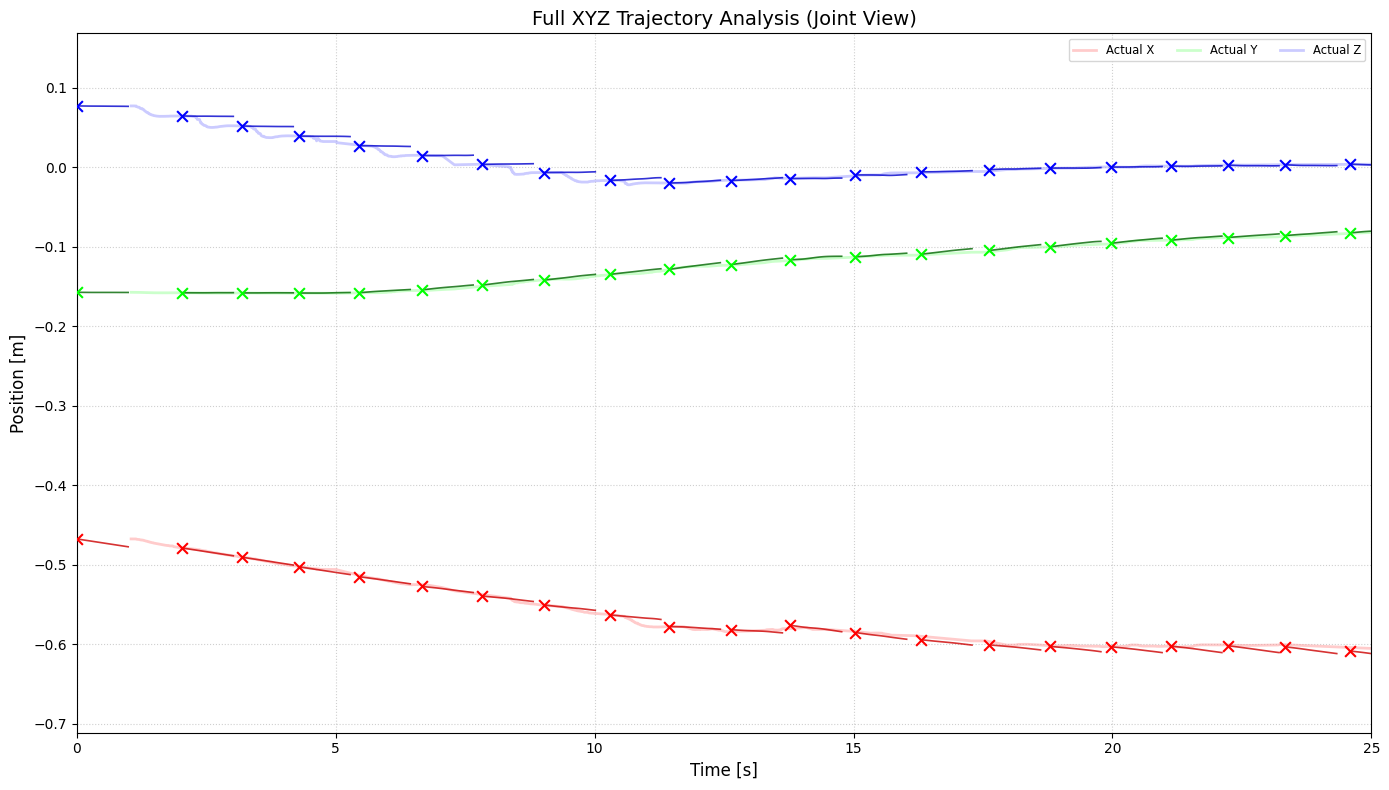

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R

class RobotIntegratedVisualizer:
    def __init__(self, run_csv, inference_csv):
        # 1. 加载数据
        self.df_run = pd.read_csv(run_csv)
        self.df_inf = pd.read_csv(inference_csv)
        
        # 2. 统一时间基准
        t0 = min(self.df_run['time_stamp'].min(), self.df_inf['obs_time'].min())
        
        self.df_run['t_rel'] = self.df_run['time_stamp'] - t0
        self.df_inf['t_rel_obs'] = self.df_inf['obs_time'] - t0
        
        # 假设发布频率是 100Hz
        dt = 0.01 
        self.df_inf['t_rel_predict'] = self.df_inf['t_rel_obs'] + self.df_inf['step_idx'] * dt

    def plot_single_canvas_xyz(self, time_range=None):
        """
        在同一个坐标系内绘制 X, Y, Z 的实际轨迹、观测点和预测段
        """
        plt.figure(figsize=(14, 8))
        
        axis_names = ['x', 'y', 'z']
        # 为三轴分配标准色：X-红, Y-绿, Z-蓝 (符合机器人坐标系惯例)
        actual_colors = ['#ff9999', '#99ff99', '#9999ff']  # 浅色背景线
        inf_colors = ['#cc0000', '#006600', '#0000cc']     # 深色预测线
        obs_colors = ['#ff0000', '#00ff00', '#0000ff']     # 观测点颜色

        cycles = self.df_inf['cycle'].unique()

        for i, axis in enumerate(axis_names):
            # A. 绘制机器人实际位置 (EE Pose)
            plt.plot(self.df_run['t_rel'], self.df_run[f'pin_{axis}'], 
                     color=actual_colors[i], label=f'Actual {axis.upper()}', 
                     linewidth=2, alpha=0.5)

            # B. 绘制模型推理结果 (Action Segments)
            for c in cycles:
                c_data = self.df_inf[self.df_inf['cycle'] == c]
                
                # 绘制预测轨迹段
                plt.plot(c_data['t_rel_predict'], c_data[f'act_{axis}'], 
                         color=inf_colors[i], linestyle='-', linewidth=1.2, alpha=0.8)
                
                # C. 绘制推理时刻的观测点 (仅第一个轴记录一次 Legend)
                plt.scatter(c_data['t_rel_obs'].iloc[0], c_data[f'obs_{axis}'].iloc[0], 
                            color=obs_colors[i], marker='x', s=60, zorder=5)

        # 装饰图表
        plt.title("Full XYZ Trajectory Analysis (Joint View)", fontsize=14)
        plt.xlabel("Time [s]", fontsize=12)
        plt.ylabel("Position [m]", fontsize=12)
        
        if time_range:
            plt.xlim(time_range)
        
        plt.grid(True, linestyle=':', alpha=0.6)
        
        # 优化图例：只显示三轴的 Actual 标签，避免重复
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        plt.legend(by_label.values(), by_label.keys(), loc='best', fontsize='small', ncol=3)

        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    # 替换为你实际的文件路径
    RUN_DATA = "/home/lgx/Project/AFP/src/il_capture/data/experiments/experiment_1773059650.csv"
    INF_DATA = "/home/lgx/Project/AFP/src/il_capture/data/experiments/inference_debug_full_1773059659.400016.csv"

    vis = RobotIntegratedVisualizer(RUN_DATA, INF_DATA)
    
    print("Generating single canvas XYZ plot...")
    # 查看推理活跃的时间段
    vis.plot_single_canvas_xyz(time_range=(0, 25))

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

class RobotJointVisualizer:
    def __init__(self, run_csv, inference_csv):
        # 1. 加载数据
        self.df_run = pd.read_csv(run_csv)
        self.df_inf = pd.read_csv(inference_csv)
        
        # 2. 统一时间基准
        t0 = min(self.df_run['time_stamp'].min(), self.df_inf['obs_time'].min())
        self.df_run['t_rel'] = self.df_run['time_stamp'] - t0
        self.df_inf['t_rel_obs'] = self.df_inf['obs_time'] - t0

        # UR5e 关节名称，用于图表标题
        self.joint_names = [
            'Shoulder Pan', 'Shoulder Lift', 'Elbow', 
            'Wrist 1', 'Wrist 2', 'Wrist 3'
        ]

    def plot_joint_comparison(self, time_range=None):
        """
        绘制六个关节的对比图：连续实际角度 (Line) + 推理时观测角度 (X)
        """
        fig, axes = plt.subplots(3, 2, figsize=(15, 12), sharex=True)
        axes = axes.flatten()

        # 获取推理数据中的唯一周期，只需每个 cycle 的第一行数据来代表“推理时刻的观测”
        df_inf_obs = self.df_inf.groupby('cycle').first().reset_index()

        for i in range(6):
            ax = axes[i]
            
            # A. 绘制实际运行中的关节角度曲线 (来自采集程序)
            # 注意：采集程序中的列名通常为 q_0, q_1...
            ax.plot(self.df_run['t_rel'], self.df_run[f'q_{i}'], 
                    color='gray', alpha=0.6, label='Actual Continuous', linewidth=1)

            # B. 绘制推理节点在推理瞬间感知到的关节角度 (来自推理程序的记录)
            # 注意：你在推理程序记录的列名为 obs_q_0, obs_q_1...
            ax.scatter(df_inf_obs['t_rel_obs'], df_inf_obs[f'obs_q_{i}'], 
                       color='red', marker='x', s=40, zorder=5, label='Inference Obs')

            # 格式化子图
            ax.set_title(f"Joint {i}: {self.joint_names[i]}", fontsize=12)
            ax.set_ylabel("Angle [rad]")
            ax.grid(True, linestyle=':', alpha=0.7)
            
            if time_range:
                ax.set_xlim(time_range)
            
            if i == 0:
                ax.legend(loc='upper right', fontsize='small')

        # 设置公共横坐标
        for j in [4, 5]:
            axes[j].set_xlabel("Time [s]")

        plt.suptitle("Joint Angles Analysis: Actual vs Inference Observation", fontsize=16)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

if __name__ == "__main__":
    # 使用你最新的数据路径
    RUN_DATA = "/home/lgx/Project/AFP/src/il_capture/data/experiments/experiment_1773059650.csv"
    INF_DATA = "/home/lgx/Project/AFP/src/il_capture/data/experiments/inference_debug_full_1773059659.400016.csv"

    joint_vis = RobotJointVisualizer(RUN_DATA, INF_DATA)
    
    print("Generating joint comparison plot...")
    # 建议查看推理活跃的时间段
    joint_vis.plot_joint_comparison(time_range=(0, 25))

FileNotFoundError: [Errno 2] No such file or directory: '/home/lgx/Project/AFP/src/il_capture/data/experiments/inference_debug_full_1773059659.400016.csv'

Showing Velocity Tracking Plot...


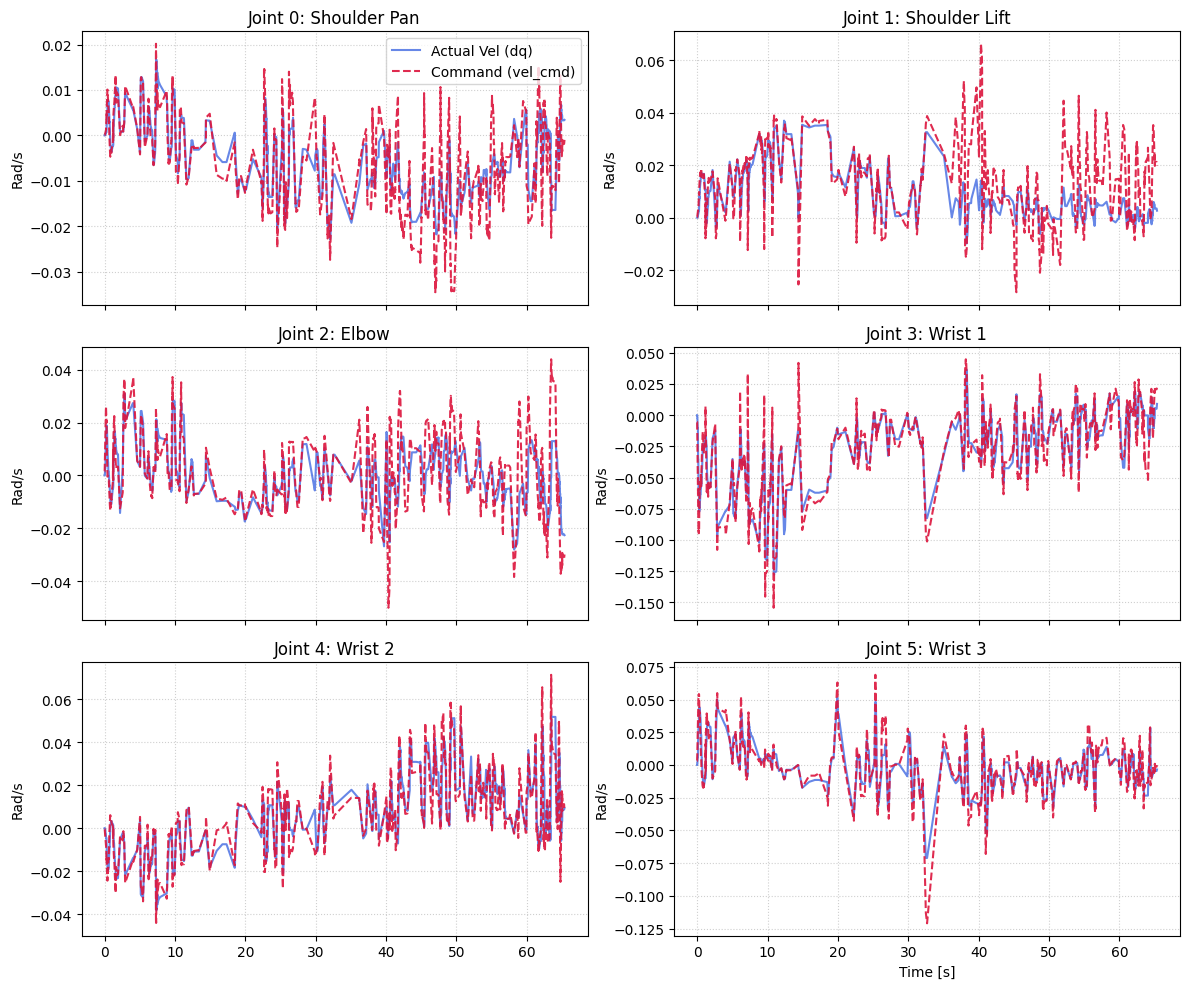

Showing Joint Effort Plot...


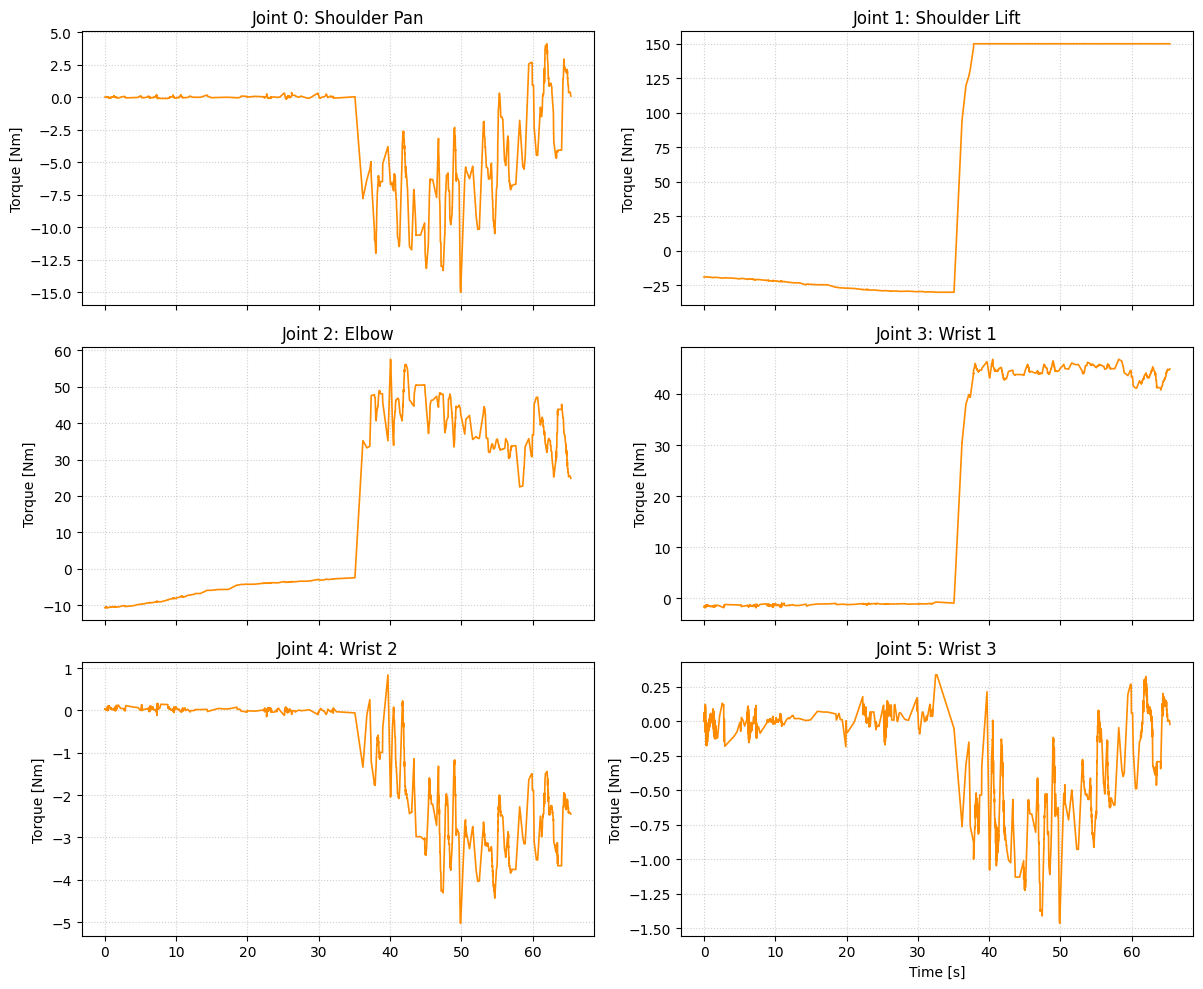

Showing End-Effector Force Tracking...


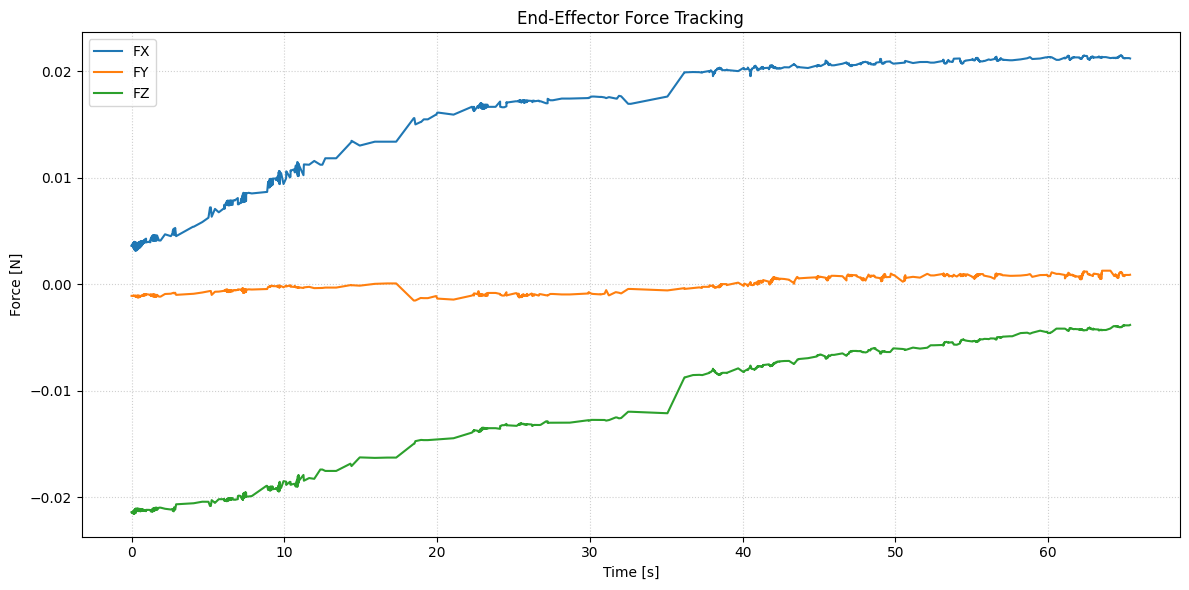

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

class RobotAnalysisVisualizer:
    def __init__(self, file_path):
        # 1. 加载数据
        self.df = pd.read_csv(file_path)
        # 时间归一化从 0 开始
        self.df['t_rel'] = self.df['time_stamp'] - self.df['time_stamp'].iloc[0]
        self.joint_names = ['Shoulder Pan', 'Shoulder Lift', 'Elbow', 'Wrist 1', 'Wrist 2', 'Wrist 3']

    def plot_velocity_tracking(self):
        """
        图 1：对比指令速度 (vel_cmd) 和 实际响应速度 (dq)
        用于评估控制器的动态响应和是否存在通信滞后
        """
        fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharex=True)
        fig.canvas.manager.set_window_title("Velocity Tracking Analysis (Command vs Actual)")
        axes = axes.flatten()

        for i in range(6):
            ax = axes[i]
            # 绘制实际速度 (dq 来自传感器)
            ax.plot(self.df['t_rel'], self.df[f'dq_{i}'], label='Actual Vel (dq)', color='royalblue', alpha=0.8)
            # 绘制指令速度 (vel_cmd 来自控制算法输出)
            ax.plot(self.df['t_rel'], self.df[f'vel_cmd_{i}'], label='Command (vel_cmd)', color='crimson', linestyle='--', alpha=0.9)
            
            ax.set_title(f"Joint {i}: {self.joint_names[i]}")
            ax.set_ylabel("Rad/s")
            ax.grid(True, linestyle=':', alpha=0.6)
            if i == 0: ax.legend(loc='upper right')

        plt.xlabel("Time [s]")
        plt.tight_layout()
        plt.show()

    def plot_joint_effort(self):
        """
        图 2：绘制六个电机的力矩 (Effort)
        用于分析负载情况及是否存在由于轨迹不连续导致的冲击
        """
        # 检查 CSV 里是否存在 effort 列
        # 如果你的录制程序没记这列，脚本会提示
        effort_cols = [f'effort_{i}' for i in range(6)]
        exists = all(col in self.df.columns for col in effort_cols)

        if not exists:
            print("\n[Warning] CSV 中未发现 effort_0~5 列。")
            print("请检查录制程序 RobotDataRecorder 中是否添加了 'row[f'effort_{i}'] = js.effort[i]'")
            return

        fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharex=True)
        fig.canvas.manager.set_window_title("Joint Effort (Torque) Analysis")
        axes = axes.flatten()

        for i in range(6):
            ax = axes[i]
            ax.plot(self.df['t_rel'], self.df[f'effort_{i}'], color='darkorange', linewidth=1.2)
            ax.set_title(f"Joint {i}: {self.joint_names[i]}")
            ax.set_ylabel("Torque [Nm]")
            ax.grid(True, linestyle=':', alpha=0.6)

        plt.xlabel("Time [s]")
        plt.tight_layout()
        plt.show()

    def plot_wrench_tracking(self):
        """
        图 3：绘制末端受力 (F_x, F_y, F_z)
        用于分析机器人与环境的交互情况，是否存在异常接触或过度振荡
        """
        fig, ax = plt.subplots(figsize=(12, 6))
        fig.canvas.manager.set_window_title("End-Effector Force Tracking")

        for axis in ['fx', 'fy', 'fz']:
            if axis in self.df.columns:
                ax.plot(self.df['t_rel'], self.df[axis], label=axis.upper())
            else:
                print(f"\n[Warning] CSV 中未发现 {axis} 列。请检查数据记录是否包含力传感器数据。")

        ax.set_title("End-Effector Force Tracking")
        ax.set_xlabel("Time [s]")
        ax.set_ylabel("Force [N]")
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend()
        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    # 替换为你实际的文件路径
    DATA_PATH = "/home/lgx/Project/AFP/src/il_capture/data/experiments/experiment_1773062839.csv"
    
    try:
        vis = RobotAnalysisVisualizer(DATA_PATH)
        
        # 任务 1: 查看速度跟踪
        print("Showing Velocity Tracking Plot...")
        vis.plot_velocity_tracking()
        
        # 任务 2: 查看关节力矩
        print("Showing Joint Effort Plot...")
        vis.plot_joint_effort()

        # 任务 3: 查看末端受力
        print("Showing End-Effector Force Tracking...")
        vis.plot_wrench_tracking()
        
    except FileNotFoundError:
        print(f"Error: {DATA_PATH} not found.")